# Import Libraries

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits   # We use fits to open the actual data file
from spectral_cube import SpectralCube
from astropy import wcs
from astropy.coordinates import SkyCoord
from astroquery.alma import Alma
from astropy.constants import c as speed_of_light
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


# Dowlaod the ALMA data using Astroquery

In [2]:
# Create ALMA object
alma = Alma()

# Set up Project code
project_code = "2019.1.00912.S"

# Query the project
results = alma.query(payload=dict(project_code=project_code))

#print(results)
#print(len(results))
#print(results.colnames)

In [3]:
# Get mous IDS

mous_ids = results["member_ous_uid"]

print("\nMOUS IDs:")
for m in mous_ids:
    print(m)



MOUS IDs:
uid://A001/X1467/X28d
uid://A001/X1467/X28d
uid://A001/X1467/X28d
uid://A001/X1467/X28d
uid://A001/X1467/X28d
uid://A001/X1467/X28d
uid://A001/X1467/X28d
uid://A001/X1467/X28b
uid://A001/X1467/X28b
uid://A001/X1467/X28b
uid://A001/X1467/X28b
uid://A001/X1467/X28b
uid://A001/X1467/X28b
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291
uid://A001/X1467/X291


In [6]:
# Get data info

data_info = alma.get_data_info(mous_ids, expand_tarfiles=True)

#print("\nData columns:")
#print(data_info.colnames)


In [7]:
urls = data_info["access_url"]

In [9]:
# Filter fits files only

cube_i_pbcor = [
    url for url in urls
    if (
        "cube" in url.lower()
        and ".i.pbcor" in url.lower()
        and ".fits" in url.lower()
    )
]

print(f"Found {len(cube_i_pbcor)} cube.i.pbcor FITS files")

for f in cube_i_pbcor:
    print(f)

Found 185 cube.i.pbcor FITS files
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw25.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw27.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw29.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw31.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw33.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw35.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw37.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw25.cube.I.pbcor.fits
https://almascience.nrao.edu/dataPortal/member.uid___A

In [10]:
#Download only pbcor fits

alma.download_files(cube_i_pbcor)

print("Download complete ✔")




INFO: Found cached file /Users/skaur/.astropy/cache/astroquery/Alma/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw25.cube.I.pbcor.fits with size 178813440 = 178813440. [astroquery.query]
INFO: Found cached file /Users/skaur/.astropy/cache/astroquery/Alma/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw27.cube.I.pbcor.fits with size 178626240 = 178626240. [astroquery.query]
INFO: Found cached file /Users/skaur/.astropy/cache/astroquery/Alma/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw29.cube.I.pbcor.fits with size 178626240 = 178626240. [astroquery.query]
INFO: Found cached file /Users/skaur/.astropy/cache/astroquery/Alma/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw31.cube.I.pbcor.fits with size 178813440 = 178813440. [astroquery.query]
INFO: Found cached file /Users/skaur/.astropy/cache/astroquery/Alma/member.uid___A001_X1467_X28d.Serpens_South_C7_sci.spw33.cube.I.pbcor.fits with size 178626240 = 178626240. [astroquery.query]
INFO: Found cached file /Users

# Load ALMA fits file

In [58]:
#pip install spectral-cube

In [120]:
#Open fits file for SiO molecule
filename = "/Users/skaur/.astropy/cache/astroquery/Alma/member.uid___A001_X1467_X28b.Serpens_South_C7_sci.spw33.cube.I.pbcor.fits" 
hdul = fits.open(filename)
data = hdul[0].data
header = hdul[0].header
wcs = WCS(header)
wcs_2d = WCS(header).celestial

In [121]:
# --------------------------------------------------
# Fix ALMA cube shape
# (stokes, freq, y, x) -> (freq, y, x)
# --------------------------------------------------
if data.ndim == 4:
    data = data[0]

cube = data  # shape: (nchan, ny, nx)

In [122]:
# --------------------------------------------------
# Get spectral axis info from header
# --------------------------------------------------
crval3 = header['CRVAL3']   # reference frequency (Hz)
cdelt3 = header['CDELT3']   # channel width (Hz)
crpix3 = header['CRPIX3']   # reference pixel
restfreq = header.get('RESTFRQ', crval3)

In [123]:
# --------------------------------------------------
# User inputs
# --------------------------------------------------
vlsr = 8.0  # km/s (your source VLSR)

# velocity range around VLSR (adjust as needed)
dv = 12# km/s on each side

# --------------------------------------------------
# Convert frequency axis → velocity axis
# (radio definition)
# --------------------------------------------------
c_kms = speed_of_light.to(u.km / u.s).value  

nchan = cube.shape[0]
channels = np.arange(nchan)

# frequency per channel
freq = crval3 + (channels - (crpix3 - 1)) * cdelt3

# velocity relative to rest frequency
velocity = c * (restfreq - freq) / restfreq


In [124]:
# --------------------------------------------------
# Find channel range corresponding to VLSR window
# --------------------------------------------------
vmin = vlsr - dv
vmax = vlsr + dv

chan_start = np.argmin(np.abs(velocity - vmax))
chan_end   = np.argmin(np.abs(velocity - vmin))

# ensure correct ordering
if chan_start > chan_end:
    chan_start, chan_end = chan_end, chan_start

print("Channel range:", chan_start, chan_end)
print("Velocity range:", velocity[chan_start], velocity[chan_end])


Channel range: 419 533
Velocity range: 20.042569893176378 -3.9914464617534633


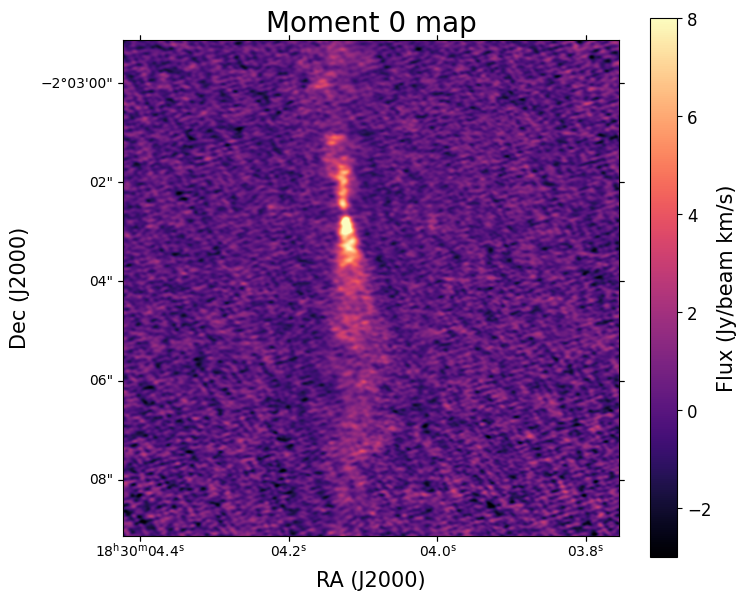

In [138]:

# --------------------------------------------------
# MOMENT 0 MAP
# --------------------------------------------------
moment0 = np.nansum(cube[chan_start:chan_end, :, :], axis=0)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8, 7))
plt.subplot(projection=wcs_2d)
plt.imshow(moment0, origin="lower", cmap="magma", vmin = -3, vmax = 8)

#Plot colorbar and zoom x,y axes
cbar = plt.colorbar(orientation="vertical") 
cbar.set_label('Flux (Jy/beam km/s)', size=15)
cbar.ax.tick_params(labelsize=12)
plt.title(f"Moment 0 map",size = 20)
plt.xlim(500, 1000) 
plt.ylim(400, 900)
plt.xlabel("RA (J2000)", size = 15)
plt.ylabel("Dec (J2000)", size = 15)
plt.show()